In [1]:
!pip install wfdb


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.8 MB/s eta 0:00:00


In [ ]:
import os
import glob # to find files in a directory
import numpy as np
import pandas as pd
import wfdb
import joblib
from tensorflow.keras.models import load_model
from scipy.signal import find_peaks
from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')


2026-03-03 17:29:55.971187: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772558996.310544      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772558996.400951      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772558997.179302      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772558997.179352      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772558997.179355      55 computation_placer.cc:177] computation placer alr

# Path

In [3]:
DATA_DIR   = '/kaggle/input/datasets/annapoornaak/phase2-dataset/ctu-chb-intrapartum-cardiotocography-database-1.0.0'
OUTPUT_DIR = '/kaggle/working/processed_data'
MODEL_PATH  = '/kaggle/input/datasets/annn51/model-files/best_mlp_ctg.keras'
SCALER_PATH = '/kaggle/input/datasets/annn51/model-files/scaler_ctg.pkl'

# STEP 1 — Load model & scaler


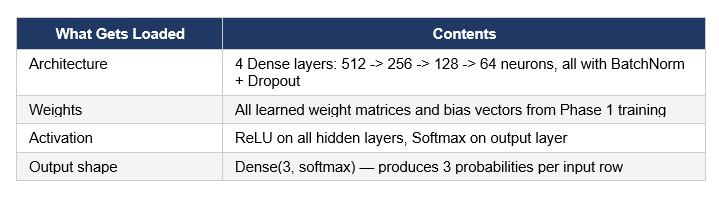

In [ ]:
model  = load_model(MODEL_PATH)
scaler = joblib.load(SCALER_PATH) # Load the scaler to ensure we know the expected number of features
print(f"✓ Model loaded. Expects {scaler.n_features_in_} features") 

I0000 00:00:1772559026.860960      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✓ Model loaded. Expects 24 features


# STEP 2 — Get all record names


In [5]:
hea_files    = glob.glob(os.path.join(DATA_DIR, '*.hea'))
record_names = sorted([os.path.basename(f).replace('.hea', '') for f in hea_files])
print(f"✓ Found {len(record_names)} records")


✓ Found 552 records


In [8]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Output directory ready: {OUTPUT_DIR}")

✓ Output directory ready: /kaggle/working/processed_data


# STEP 3 — Extract metadata from .hea files → metadata.csv


In [ ]:
def extract_metadata(data_dir, record_names):
    all_data = []
    for rec_name in record_names:
        try:
            record   = wfdb.rdheader(os.path.join(data_dir, rec_name)) # Read only the header to access metadata
            metadata = {'Patient_ID': rec_name}# Start with the record name as a unique identifier
            for comment in record.comments: # Process each comment line to extract key-value pairs
                parts = comment.split(maxsplit=1) # Split into key and value
                if len(parts) == 2:
                    key, value = parts[0].strip(), parts[1].strip()# Only consider keys that are not flags (starting with '-') and do not contain '!' or 'NotReady'
                    if not key.startswith('-') and '!' not in key and 'NotReady' not in key: # Attempt to convert value to float, otherwise keep as string
                        try:
                            metadata[key] = float(value) # Convert to float if possible why? Because many metadata values are numeric (like age, weight, etc.) and converting them allows for easier analysis later on. If conversion fails, we keep the original string value.
                        except ValueError:
                            metadata[key] = value
            all_data.append(metadata) 
        except Exception as e:
            print(f"  Metadata error {rec_name}: {e}")
    return pd.DataFrame(all_data)

df_metadata = extract_metadata(DATA_DIR, record_names)
df_metadata.to_csv(os.path.join(OUTPUT_DIR, 'metadata.csv'), index=False)
print(f"✓ Metadata saved: {df_metadata.shape} → metadata.csv")
print(f"  Columns: {df_metadata.columns.tolist()}")

✓ Metadata saved: (552, 36) → metadata.csv
  Columns: ['Patient_ID', 'pH', 'BDecf', 'pCO2', 'BE', 'Apgar1', 'Apgar5', 'NICU', 'Seizures', 'HIE', 'Intubation', 'Main', 'Other', 'Gest.', 'Weight(g)', 'Sex', 'Age', 'Gravidity', 'Parity', 'Diabetes', 'Hypertension', 'Preeclampsia', 'Liq.', 'Pyrexia', 'Meconium', 'Presentation', 'Induced', 'I.stage', 'NoProgress', 'CK/KP', 'II.stage', 'Deliv.', 'dbID', 'Rec.', 'Pos.', 'Sig2Birth']


# STEP 4 — Signal processing functions


### Signal Preparation Steps

1. **Read CTG Record**  
   Load the WFDB record to access **FHR (fetal heart rate)** and **UC (uterine contraction)** signals.

2. **Extract Signals**  
   - `fhr = record.p_signal[:,0]` → Fetal heart rate  
   - `uc  = record.p_signal[:,1]` → Uterine contractions  

3. **Get Sampling Frequency**  
   Obtain the sampling rate `fs` (typically **4 Hz**, meaning 4 samples per second).

4. **Handle Missing Values**  
   Replace **0 values with NaN** because 0 represents missing or invalid measurements.

5. **Ensure Full Seconds of Data**  
   Truncate the signal length to a **multiple of the sampling frequency** so it can be grouped into full seconds.

6. **Downsample to 1 Hz**  
   Average every **4 samples → 1 value per second** to reduce noise and data size.

7. **Select Last Hour of Data**  
   Return only the **last 3600 seconds (1 hour)** of the processed signals.

### Baseline Estimation

* The baseline fetal heart rate is estimated using a sliding window approach.  
* A 10-minute window (600 samples at 1 Hz) is centered around each time point of the signal.  
* Within this window, the median fetal heart rate is calculated to represent the baseline value.  
* The median is used instead of the mean to reduce the effect of accelerations, decelerations, and noise.  
* Repeating this process for every time point produces a smooth baseline signal that reflects the typical heart rate around which fluctuations occur.

### Acceleration and Deceleration Detection

The difference between the fetal heart rate and the estimated baseline is calculated as:

diff = FHR − baseline

Accelerations and decelerations are detected by identifying continuous segments where this difference exceeds specific thresholds.

- **AC (Accelerations):** FHR ≥ baseline + 15 bpm for at least 15 seconds.
- **FM (Fetal Movements):** Approximated using the same condition as accelerations.
- **DL (Light Decelerations):** FHR between 15 and 45 bpm below baseline for at least 15 seconds.
- **DS (Severe Decelerations):** FHR ≥45 bpm below baseline for at least 15 seconds.
- **DP (Prolonged Decelerations):** FHR ≥15 bpm below baseline lasting at least 120 seconds.

The function `count_events()` scans the signal and counts continuous segments that satisfy these conditions for the required duration.

### Variability Features

Variability features describe fluctuations in the fetal heart rate (FHR) signal over time and are important indicators of fetal autonomic nervous system activity. These features are computed by dividing the signal into **1-minute epochs (60 samples at 1 Hz)**.

---

### Short-Term Variability (STV)

Short-term variability measures **beat-to-beat fluctuations** in fetal heart rate within an epoch.

For an epoch with $N$ samples, STV is calculated as:

$$
STV = \frac{1}{N-1} \sum_{i=1}^{N-1} \left| FHR_{i+1} - FHR_i \right|
$$

where $FHR_i$ is the fetal heart rate at time $i$.

This represents the **average absolute difference between consecutive heart rate values**.

---

### MSTV (Mean Short-Term Variability)

MSTV represents the **average STV across all epochs**.

If there are $E$ epochs:

$$
MSTV = \frac{1}{E} \sum_{j=1}^{E} STV_j
$$

where $STV_j$ is the short-term variability calculated for epoch $j$.

---

### ASTV (Abnormal Short-Term Variability)

ASTV measures the **percentage of epochs where STV exceeds a threshold** (3 bpm in this implementation).

$$
ASTV = \frac{\text{Number of epochs where } STV > 3}{\text{Total number of epochs}} \times 100
$$

This indicates the proportion of time where short-term variability is relatively high.

---

### Long-Term Variability (LTV)

Long-term variability captures **slower changes in fetal heart rate** within an epoch.

Each 1-minute epoch is divided into **four 15-second segments**. The median heart rate of each segment is calculated.

Let the medians be:

$$
m_1, m_2, m_3, m_4
$$

Then LTV is computed as:

$$
LTV = \max(m_1, m_2, m_3, m_4) - \min(m_1, m_2, m_3, m_4)
$$

This represents the **range of median heart rates within the epoch**.

---

### MLTV (Mean Long-Term Variability)

MLTV is the **average LTV across all epochs**.

$$
MLTV = \frac{1}{E} \sum_{j=1}^{E} LTV_j
$$

where $LTV_j$ is the long-term variability for epoch $j$.

---

### ALTV (Abnormal Long-Term Variability)

ALTV measures the **percentage of epochs where LTV exceeds a threshold** (10 bpm).

$$
ALTV = \frac{\text{Number of epochs where } LTV > 10}{\text{Total number of epochs}} \times 100
$$

This feature reflects how frequently large long-term fluctuations occur in the fetal heart rate signal.

### Histogram Features

**Mode:**  
The mode represents the most frequently occurring fetal heart rate value. It is determined by identifying the histogram bin with the highest count.

$$
Mode = edges[\arg\max(counts)]
$$

This indicates the heart rate level where the signal is most concentrated.

**Tendency:**  
Tendency describes the skewness of the fetal heart rate distribution. It is computed as the sign of the skewness value.

$$
Tendency = sign(skew(FHR))
$$

A value of −1 indicates left-skewness, 0 indicates a symmetric distribution, and 1 indicates right-skewness.

In [ ]:
def prepare_signal(record_name):
    record  = wfdb.rdrecord(os.path.join(DATA_DIR, record_name)) # Read the full record to access signal data contains both FHR and UC
    fhr     = record.p_signal[:, 0]
    uc      = record.p_signal[:, 1]
    fs      = record.fs # Sampling frequency (should be 4 Hz))
    fhr     = np.where(fhr == 0, np.nan, fhr) # Replace 0 with NaN for FHR why? Because 0 is not a valid heart rate and likely represents missing data  
    uc      = np.where(uc == 0, np.nan, uc)   # Replace 0 with NaN for UC
    n       = (len(fhr) // fs) * fs # Ensure we only take full seconds of data why? Because we will be downsampling to 1 Hz by averaging every 4 samples, so we need a length that is a multiple of the sampling frequency (4) to avoid incomplete seconds at the end
    if n == 0: # If the record is too short to contain even one second of data, return None
        return None, None
    fhr_1hz = np.nanmean(fhr[:n].reshape(-1, fs), axis=1) # Downsample FHR to 1 Hz by averaging every 4 samples 
    uc_1hz  = np.nanmean(uc[:n].reshape(-1,  fs), axis=1)# Downsample UC to 1 Hz by averaging every 4 samples
    return fhr_1hz[-3600:], uc_1hz[-3600:] # Return only the last 3600 seconds (1 hour) of data

def estimate_baseline(fhr, window_min=10):
    window   = window_min * 60 # Convert minutes to seconds how many seconds in the window? 10 minutes * 60 seconds/minute = 600 seconds
    baseline = np.full_like(fhr, np.nan) # Initialize baseline array with NaN values    
    for i in range(len(fhr)): # For each second in the FHR signal, we will calculate the baseline using a moving window approach
        start   = max(0, i - window // 2) # Calculate the start index of the window, ensuring it does not go below 0
        end     = min(len(fhr), i + window // 2) # Calculate the end index of the window, ensuring it does not go beyond the length of the FHR signal
        segment = fhr[start:end] # Extract the segment of FHR data within the window
        if np.sum(~np.isnan(segment)) > 0: # If there are valid (non-NaN) values in the segment, calculate the median and assign it to the baseline at index i
            baseline[i] = np.nanmedian(segment)    # Use the median of the segment as the baseline value for the current second. The median is used instead of the mean to reduce the influence of outliers and provide a more robust estimate of the central tendency of the FHR values within the window. 
    return baseline

def count_events(mask, min_dur): # min_dur is the minimum duration in seconds for an event to be counted
    events, in_event, dur = 0, False, 0 # Initialize the event count, a flag to indicate if we are currently in an event, and a duration counter
    for val in mask:
        if val:
            in_event, dur = True, dur + 1 # If the current value in the mask is True, we are in an event, so we set the in_event flag to True and increment the duration counter
        else:
            if in_event and dur >= min_dur: # If we were in an event and the duration meets the minimum requirement, we count it as an event  how? We check if the in_event flag is True (indicating we were in an event) and if the duration counter is greater than or equal to the minimum duration. If both conditions are met, we increment the event count by 1.  We check these conditions when we encounter a False value in the mask, which indicates the end of a potential event. If the event meets the duration requirement, we count it before resetting the in_event flag and duration counter for the next potential event. 
                events += 1
            in_event, dur = False, 0 # If the current value in the mask is False, we are not in an event, so we reset the in_event flag and duration counter
    if in_event and dur >= min_dur: # After the loop, we check if we ended while still in an event that meets the duration requirement, and if so, we count it as well  
        events += 1
    return events

def extract_all_features(record_name):
    fhr, uc = prepare_signal(record_name)# Prepare the FHR and UC signals by reading the record, downsampling to 1 Hz, and taking only the last hour of data. This function will return two arrays: fhr (fetal heart rate) and uc (uterine contractions), which will be used for feature extraction.

    if fhr is None or np.sum(~np.isnan(fhr)) < 100:# If the FHR signal is None or has fewer than 100 valid (non-NaN) values, we consider it insufficient for feature extraction and return None
        return None

    baseline  = estimate_baseline(fhr)
    fhr_clean = fhr[~np.isnan(fhr)] # Create a cleaned version of the FHR signal by removing NaN values, which will be used for feature extraction to ensure that calculations are based on valid heart rate data. This is important for accurate feature extraction, as NaN values can skew statistics and lead to incorrect conclusions about fetal well-being.
    diff      = fhr - baseline

    # — Variability —
    stv_epochs, ltv_epochs = [], []
    for i in range(len(fhr) // 60): #Divide Signal Into 1-Minute Epochs 
        epoch = fhr[i*60:(i+1)*60] # For each 1-minute epoch of the FHR signal, we will calculate short-term variability (STV) and long-term variability (LTV). 
        if np.sum(~np.isnan(epoch)) < 10: # If the epoch has fewer than 10 valid (non-NaN) values, we consider it insufficient for variability calculation and skip it to avoid unreliable estimates of STV and LTV, which can be important indicators of fetal well-being and potential distress.
            continue
        stv_epochs.append(np.mean(np.abs(np.diff(epoch[~np.isnan(epoch)])))) # Calculate short-term variability (STV) for the epoch as the mean of the absolute differences between consecutive valid FHR values, which captures the beat-to-beat variability in the fetal heart rate and can be an important indicator of fetal well-being and potential distress.
        quarters = np.array_split(epoch, 4) # Divide the epoch into 4 equal quarters to calculate long-term variability (LTV) as the difference between the maximum and minimum median heart rates across these quarters, which captures longer-term fluctuations in the fetal heart rate and can provide insights into fetal well-being and potential distress.
        medians  = [np.nanmedian(q) for q in quarters] # Calculate the median heart rate for each quarter of the epoch, ignoring NaN values, to use in the calculation of long-term variability (LTV). The median is used to provide a robust measure of central tendency for each quarter, which helps to capture the overall trend in heart rate across the epoch while minimizing the influence of outliers.
        ltv_epochs.append(np.max(medians) - np.min(medians)) # Calculate long-term variability (LTV) for the epoch as the difference between the maximum and minimum median heart rates across the four quarters, which captures longer-term fluctuations in the fetal heart rate and can provide insights into fetal well-being and potential distress. A higher LTV may indicate better fetal well-being, while a lower LTV may be a sign of potential distress.

    stv_epochs = np.array(stv_epochs) if stv_epochs else np.array([0]) # Convert the list of STV epochs to a NumPy array for easier calculations, and if there are no valid epochs, use an array with a single value of 0 to avoid issues with empty arrays in subsequent calculations. This allows us to calculate features related to STV without encountering errors due to empty data.
    ltv_epochs = np.array(ltv_epochs) if ltv_epochs else np.array([0]) 

    # — Histogram — # distribution of FHR values to identify common heart rate ranges and potential abnormalities. This can provide insights into fetal well-being and help detect potential issues with the fetal heart rate patterns.
    # count is the number of FHR values that fall into each bin defined by edges, and edges are the boundaries of the bins.
    counts, edges = np.histogram(fhr_clean, bins=np.arange(50, 200, 1))# Create a histogram of the cleaned FHR signal using bins from 50 to 200 bpm with a width of 1 bpm. This histogram will help us understand the distribution of FHR values and identify common heart rate ranges, which can be important for assessing fetal well-being and detecting potential abnormalities.
    peaks, _      = find_peaks(counts)# Find peaks in the histogram counts to identify the most common FHR values, which can provide insights into the fetal heart rate distribution and potential abnormalities.  libary function that identifies local maxima in the histogram counts, which correspond to the most frequently occurring FHR values. These peaks can be indicative of the fetal heart rate patterns and may help in assessing fetal well-being.
    uc_clean      = np.where(np.isnan(uc), 0, uc) # Replace NaN values in the UC signal with 0 to prepare for peak detection, as NaN values can interfere with the peak finding process. This allows us to identify peaks in the uterine contraction signal, which can provide insights into the frequency and intensity of contractions, and their relationship with fetal heart rate patterns.
    uc_peaks, _   = find_peaks(uc_clean, height=np.nanmean(uc_clean), distance=60)   # Find peaks in the cleaned UC signal that are above the average UC level and at least 60 seconds apart, which can help identify significant uterine contractions and their potential impact on fetal heart rate patterns. This uses the find_peaks function to identify peaks in the uterine contraction signal, with a height threshold set to the average UC level to focus on significant contractions, and a distance parameter to ensure that identified peaks are at least 60 seconds apart, which is important for distinguishing individual contractions.

    return {
        # Basic
        'LB':       round(float(np.nanmean(baseline)), 2), # Average baseline heart rate     over the last hour, rounded to 2 decimal places. This feature captures the central tendency of the fetal heart rate, which can be an important indicator of fetal well-being.
        'Mean':     round(float(np.nanmean(fhr_clean)), 4),
        'Median':   round(float(np.nanmedian(fhr_clean)), 4),
        'Variance': round(float(np.nanvar(fhr_clean)), 4),
        'Min':      round(float(np.nanmin(fhr_clean)), 4),  
        'Max':      round(float(np.nanmax(fhr_clean)), 4),
        'Width':    round(float(np.nanmax(fhr_clean) - np.nanmin(fhr_clean)), 4),
        # Accels / Decels
        'AC':       count_events(diff >= 15, 15), # approximated from FHR, count the number of accelerations (AC) where the difference between the FHR and the baseline is greater than or equal to 15 bpm for at least 15 seconds. This feature captures the presence of accelerations, which are generally considered a sign of fetal well-being.
        'FM':       count_events(diff >= 15, 15),   # approximated from FHR
        'DL':       count_events((diff <= -15) & (diff > -45), 15), # light decelerations (DL) where the difference between the FHR and the baseline is less than or equal to -15 bpm but greater than -45 bpm for at least 15 seconds. This feature captures the presence of light decelerations, which can be a sign of fetal stress but are not as concerning as deep decelerations.
        'DS':       count_events(diff <= -45, 15), # severe decelerations (DS) where the difference between the FHR and the baseline is less than or equal to -45 bpm for at least 15 seconds. This feature captures the presence of severe decelerations, which can be a sign of significant fetal distress and may require immediate medical attention.
        'DP':       count_events(diff <= -15, 120), # prolonged decelerations (DP) where the difference between the FHR and the baseline is less than or equal to -15 bpm for at least 120 seconds. This feature captures the presence of prolonged decelerations, which can be a sign of sustained fetal distress and may require medical intervention.
        # Variability
        'ASTV':     round(float(np.mean(stv_epochs < 3)  * 100), 4), # Percentage of short-term variability (STV) epochs greater than 3 bpm, rounded to 4 decimal places. This feature captures the proportion of time during the last hour where the beat-to-beat variability in the fetal heart rate is above a certain threshold, which can be an important indicator of fetal well-being and potential distress.
        'MSTV':     round(float(np.nanmean(stv_epochs)), 4), # Average short-term variability (STV) over the last hour, rounded to 4 decimal places. This feature captures the average beat-to-beat variability in the fetal heart rate, which can be an important indicator of fetal well-being and potential distress.
        'ALTV':     round(float(np.mean(ltv_epochs < 10) * 100), 4), 
        'MLTV':     round(float(np.nanmean(ltv_epochs)), 4), 
        # Histogram
        'Nmax':     int(len(peaks)), # Number of peaks in the FHR histogram, which can indicate the number of common heart rate values and provide insights into the fetal heart rate distribution.
        'Nzeros':   int(np.sum(counts == 0)), # Number of bins in the FHR histogram that have zero counts, which can indicate the range of heart rate values that are not present in the fetal heart rate distribution and may provide insights into potential abnormalities.
        'Mode':     float(edges[np.argmax(counts)]),# The mode of the FHR distribution, calculated as the bin edge corresponding to the maximum count in the histogram, which can indicate the most common heart rate value and provide insights into fetal well-being.
        'Tendency': int(np.sign(skew(fhr_clean))), # The skewness of the FHR distribution, which can indicate the tendency of the heart rate values to be more concentrated on one side of the distribution. A positive skew indicates a longer tail on the right side (higher heart rates), while a negative skew indicates a longer tail on the left side (lower heart rates). This feature can provide insights into fetal well-being and potential abnormalities.
        # UC
        'UC':       len(uc_peaks),
    }

# STEP 5 — Extract features for all records


In [ ]:
all_features = []
skipped      = []

for i, rec in enumerate(record_names): # Loop through each record name and extract features using the extract_all_features function. We will keep track of successfully extracted features in the all_features list and any records that were skipped due to errors or insufficient data in the skipped list. This allows us to build a comprehensive dataset of features for all records while also identifying any issues with specific records.
    try:
        feats = extract_all_features(rec)
        if feats is None:
            skipped.append(rec)
            continue
        feats['Patient_ID'] = rec
        all_features.append(feats)
        if (i+1) % 50 == 0:
            print(f"  Processed {i+1}/{len(record_names)}")
    except Exception as e:
        print(f"  Failed {rec}: {e}")
        skipped.append(rec)

df_features = pd.DataFrame(all_features)
print(f"\n✓ Features extracted: {df_features.shape}")
print(f"  Skipped: {len(skipped)} records")

# Save full features + metadata together
df_features['Patient_ID'] = df_features['Patient_ID'].astype(str)
df_metadata['Patient_ID'] = df_metadata['Patient_ID'].astype(str)
df_combined = df_features.merge(df_metadata, on='Patient_ID', how='left')
df_combined.to_csv(os.path.join(OUTPUT_DIR, 'features_and_metadata.csv'), index=False)
print(f"✓ Combined features+metadata saved: {df_combined.shape} → features_and_metadata.csv")

  Processed 50/552
  Processed 100/552
  Processed 150/552
  Processed 200/552
  Processed 250/552
  Processed 300/552
  Processed 350/552
  Processed 400/552
  Processed 450/552
  Processed 500/552
  Processed 550/552

✓ Features extracted: (552, 22)
  Skipped: 0 records
✓ Combined features+metadata saved: (552, 57) → features_and_metadata.csv


# STEP 6 — Align features to UCI order & generate labels


In [ ]:
# b = start sample (always 0 for our 60-min segments)
# e = end sample (always 3600 for our 60-min segments)
# LBE = baseline by medical expert (we use our estimated baseline as approximation)

SCALER_FEATURES = ['b', 'e', 'LBE', 'LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV',
                   'DL', 'DS', 'DP', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros',
                   'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

df_input = df_features.copy()
df_input['b']   = 0       # start instant
df_input['e']   = 3600    # end instant
df_input['LBE'] = df_input['LB']   # use computed baseline as expert baseline

df_input = df_input[SCALER_FEATURES].fillna(0)

print(f"Input shape: {df_input.shape}")
print(f"Columns match scaler: {df_input.columns.tolist() == scaler.feature_names_in_.tolist()}")

X_scaled = scaler.transform(df_input) # Scale the input features using the loaded scaler to ensure that the features are on the same scale as the data used to train the model, which is important for accurate predictions. This transformation will apply the same scaling parameters (e.g., mean and standard deviation) that were calculated from the training data, allowing the model to make meaningful predictions based on the input features.
probs    = model.predict(X_scaled) # Use the loaded model to predict probabilities for each class (Normal, Suspect, Pathologic) based on the scaled input features. The output will be an array of probabilities for each class, which we can then use to determine the predicted label for each patient.
preds    = np.argmax(probs, axis=1) # Determine the predicted label for each patient by taking the index of the class with the highest predicted probability, which will give us a numerical label (0 for Normal, 1 for Suspect, 2 for Pathologic) that we can then map to the corresponding class name for easier interpretation of the results.
label_map = {0: 'Normal', 1: 'Suspect', 2: 'Pathologic'}

df_labels = pd.DataFrame({
    'Patient_ID':      df_features['Patient_ID'],
    'label':           preds,
    'label_name':      [label_map[p] for p in preds],
    'prob_normal':     probs[:, 0].round(4),
    'prob_suspect':    probs[:, 1].round(4),
    'prob_pathologic': probs[:, 2].round(4),
})
df_labels.to_csv(os.path.join(OUTPUT_DIR, 'patient_labels.csv'), index=False)

print(f"\n✓ Labels saved → patient_labels.csv")
print(f"\nLabel distribution:")
print(df_labels['label_name'].value_counts())
print(df_labels.head(10))

Input shape: (552, 24)
Columns match scaler: True


I0000 00:00:1772559381.385914     129 service.cc:152] XLA service 0x7df9f4003ed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772559381.385953     129 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772559381.630495     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/18 ━━━━━━━━━━━━━━━━━━━━ 16s 989ms/step

I0000 00:00:1772559382.188068     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step 

✓ Labels saved → patient_labels.csv

Label distribution:
label_name
Normal        464
Pathologic     58
Suspect        30
Name: count, dtype: int64
  Patient_ID  label  label_name  prob_normal  prob_suspect  prob_pathologic
0       1001      0      Normal       0.9992        0.0008           0.0000
1       1002      2  Pathologic       0.0048        0.0223           0.9729
2       1003      0      Normal       1.0000        0.0000           0.0000
3       1004      0      Normal       1.0000        0.0000           0.0000
4       1005      0      Normal       1.0000        0.0000           0.0000
5       1006      0      Normal       0.9635        0.0203           0.0162
6       1007      2  Pathologic       0.0056        0.0416           0.9527
7       1008      0      Normal       1.0000        0.0000           0.0000
8       1009      0      Normal       1.0000        0.0000           0.0000
9       1010      0      Normal       1.0000      

In [13]:
print("Scaler expects these features:")
print(scaler.feature_names_in_.tolist())
print(f"Total: {len(scaler.feature_names_in_)}")

Scaler expects these features:
['b', 'e', 'LBE', 'LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL', 'DS', 'DP', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']
Total: 24


# STEP 7 — Save labels CSV


In [15]:
df_labels = pd.DataFrame({
    'Patient_ID':      df_features['Patient_ID'],
    'label':           preds,
    'label_name':      [label_map[p] for p in preds],
    'prob_normal':     probs[:, 0].round(4),
    'prob_suspect':    probs[:, 1].round(4),
    'prob_pathologic': probs[:, 2].round(4),
})
df_labels.to_csv(os.path.join(OUTPUT_DIR, 'patient_labels.csv'), index=False)

print(f"\n✓ Labels saved: {df_labels.shape} → patient_labels.csv")
print(f"\nLabel distribution:")
print(df_labels['label_name'].value_counts())
print(f"\nSample output:")
print(df_labels.head(10))


✓ Labels saved: (552, 6) → patient_labels.csv

Label distribution:
label_name
Normal        464
Pathologic     58
Suspect        30
Name: count, dtype: int64

Sample output:
  Patient_ID  label  label_name  prob_normal  prob_suspect  prob_pathologic
0       1001      0      Normal       0.9992        0.0008           0.0000
1       1002      2  Pathologic       0.0048        0.0223           0.9729
2       1003      0      Normal       1.0000        0.0000           0.0000
3       1004      0      Normal       1.0000        0.0000           0.0000
4       1005      0      Normal       1.0000        0.0000           0.0000
5       1006      0      Normal       0.9635        0.0203           0.0162
6       1007      2  Pathologic       0.0056        0.0416           0.9527
7       1008      0      Normal       1.0000        0.0000           0.0000
8       1009      0      Normal       1.0000        0.0000           0.0000
9       1010      0      Normal       1.0000        0.0000       